# Workbook 3 Model Training & Evaluation

Training of three models and comparison between them:

| Model | Type | Purpose |
|---|---|---|
| **Naive persistence** | Baseline | Predict t+1 = last observed value |
| **Ridge regression** | Linear | Check if linear patterns are enough |
| **XGBoost** | Gradient boosting | Primary model: handles non-linearity + cross-sector patterns |

### XGBoost as a model test
- ~14 quarterly observations per sector = too few for LSTM/Transformer
- Cross-sectional: 10 sectors share one model via sector dummies
- Handles COVID-era outliers robustly via tree splits
- Native feature importances → interpretable results


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load feature dataset
df_features = pd.read_csv('../artifacts/processed/features_latest.csv', parse_dates=['period'])
print(f"Feature dataset: {df_features.shape}")
print(f"Periods: {df_features['period'].min().date()} → {df_features['period'].max().date()}")


Feature dataset: (180, 44)
Periods: 2019-04-01 → 2023-07-01


In [2]:
from src.features import get_feature_columns, time_split

# Filter to 2019-2023 only — excludes 2024/2025 where new_enterprises=0 (DEMO14 publication lag)
df_features = df_features[df_features['period'] < '2024-01-01'].copy()

feature_cols = get_feature_columns(df_features)
df_train, df_test = time_split(df_features, test_quarters=4)

print(f"Features: {len(feature_cols)}")
print(f"Train size: {len(df_train):,} | Test size: {len(df_test):,}")

2026-04-16 17:21:42,406 [INFO] Time split: train=140 rows (2019-04 → 2022-07), test=40 rows (2022-10 → 2023-07)


Features: 33
Train size: 140 | Test size: 40


## 3.1 Baseline: Naive persistence
Before training anything, a floor is established.
The naive model predicts: **vitality(t+1) = vitality(t)**
This is equivalent to using the lag-1 feature directly as the prediction.


In [3]:
from src.model import naive_baseline

baseline = naive_baseline(df_test, feature_cols)
print("Naive baseline metrics (test set):")
for k, v in baseline['metrics'].items():
    print(f"  {k}: {v:.4f}")


2026-04-16 17:21:42,414 [INFO] Naive baseline test metrics: {'mae': 0.09518, 'rmse': 0.13543, 'r2': -9.86644, 'directional_accuracy': 0.9}


Naive baseline metrics (test set):
  mae: 0.0952
  rmse: 0.1354
  r2: -9.8664
  directional_accuracy: 0.9000


## 3.2 Ridge Regression (linear baseline)
Ridge regression regularises the coefficients to prevent overfitting
on the many correlated lag features. It tells how much can be
explained with purely linear relationships


In [4]:
from src.model import train_ridge

ridge_result = train_ridge(df_train, df_test, feature_cols)
print("Ridge test metrics:")
for k, v in ridge_result['metrics'].items():
    print(f"  {k}: {v:.4f}")


2026-04-16 17:21:42,423 [INFO] Ridge test metrics: {'mae': 0.11225, 'rmse': 0.14431, 'r2': -11.3371, 'directional_accuracy': 0.86667}


Ridge test metrics:
  mae: 0.1123
  rmse: 0.1443
  r2: -11.3371
  directional_accuracy: 0.8667


## 3.3 XGBoost

**Hyperparameter choices explained:**

| Parameter | Value | Reason |
|---|---|---|
| `max_depth=4` | 4 | Shallow trees → less overfitting on small data |
| `learning_rate=0.05` | 0.05 | Slow learning → more trees, more stable |
| `n_estimators=300` | 300 | Max trees (early stopping prevents over-boosting) |
| `subsample=0.8` | 0.8 | 80% row sampling per tree → regularisation |
| `colsample_bytree=0.8` | 0.8 | 80% feature sampling → feature diversity |
| `early_stopping_rounds=30` | 30 | Halt if validation MAE doesn't improve for 30 rounds |


In [5]:
from src.model import train_xgboost

xgb_result = train_xgboost(df_train, df_test, feature_cols)
print("XGBoost test metrics:")
for k, v in xgb_result['metrics'].items():
    print(f"  {k}: {v:.4f}")
print(f"\nBest iteration: {xgb_result['estimator'].best_iteration}")


2026-04-16 17:21:42,462 [INFO] XGBoost test metrics: {'mae': 0.23854, 'rmse': 0.25367, 'r2': -37.12411, 'directional_accuracy': 0.33333}
2026-04-16 17:21:42,462 [INFO]   Best iteration: 55
2026-04-16 17:21:42,463 [INFO]   Top features: [('net_growth_rate_lag1', np.float32(0.17211343)), ('vitality_score_lag1', np.float32(0.13797668)), ('birth_rate_lag1', np.float32(0.13186213)), ('vitality_score_roll8_mean', np.float32(0.050955985)), ('vitality_score_roll4_std', np.float32(0.046826392)), ('year', np.float32(0.04480991)), ('vitality_score_roll4_mean', np.float32(0.042817213)), ('sector_6', np.float32(0.035938848)), ('vitality_score_roll8_std', np.float32(0.033862486)), ('net_growth_rate_lag4', np.float32(0.028183239))]


XGBoost test metrics:
  mae: 0.2385
  rmse: 0.2537
  r2: -37.1241
  directional_accuracy: 0.3333

Best iteration: 55


## 3.4 Model Comparison


In [6]:
import pandas as pd

comparison = pd.DataFrame({
    'Naive': baseline['metrics'],
    'Ridge': ridge_result['metrics'],
    'XGBoost': xgb_result['metrics'],
}).T.round(4)

print("Model comparison (test set):")
print(comparison.to_string())


Model comparison (test set):
            mae    rmse       r2  directional_accuracy
Naive    0.0952  0.1354  -9.8664                0.9000
Ridge    0.1122  0.1443 -11.3371                0.8667
XGBoost  0.2385  0.2537 -37.1241                0.3333


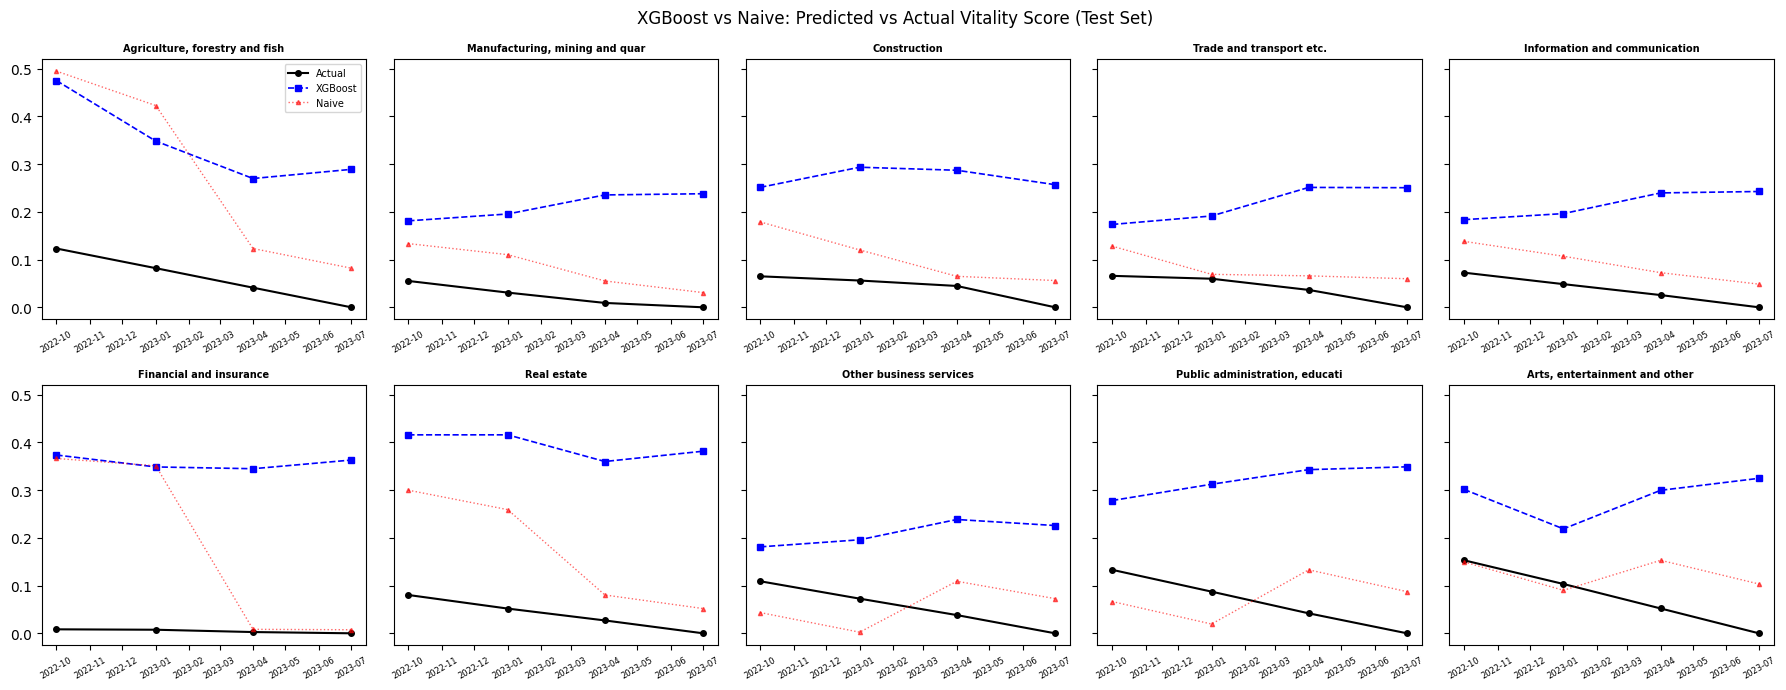

In [7]:
from src.dst_client import DSTClient

# Pull sector names from DST API
client = DSTClient(language='en')
info = client.get_table_info('DEMO14')
branch_var = next(v for v in info['variables'] if v['id'] == 'BRANCHEDB0710')
sector_names = {
    v['id']: v['text'].split(' ', 1)[1] if ' ' in v['text'] else v['text']
    for v in branch_var['values']
    if v['id'] not in ('TOT', '11')
}

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
axes = axes.flatten()

df_test_with_pred = df_test.copy()
df_test_with_pred['y_pred_xgb'] = xgb_result['predictions']
lag1_col = next(c for c in feature_cols if c.endswith('_lag1') and 'vitality' in c)
df_test_with_pred['y_pred_naive'] = df_test[lag1_col].values

sectors = sorted(df_test['sector'].unique())
for i, sector in enumerate(sectors[:10]):
    sub = df_test_with_pred[df_test_with_pred['sector'] == sector].sort_values('period')
    ax = axes[i]
    ax.plot(sub['period'], sub['target'], 'k-o', markersize=4, linewidth=1.5, label='Actual')
    ax.plot(sub['period'], sub['y_pred_xgb'], 'b--s', markersize=4, linewidth=1.2, label='XGBoost')
    ax.plot(sub['period'], sub['y_pred_naive'], 'r:^', markersize=3, linewidth=1.0, label='Naive', alpha=0.6)
    label = sector_names.get(str(sector), str(sector))
    ax.set_title(label[:30], fontsize=7, fontweight='bold')
    ax.tick_params(axis='x', labelsize=6, rotation=30)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('XGBoost vs Naive: Predicted vs Actual Vitality Score (Test Set)', fontsize=12)
plt.tight_layout()
plt.savefig('../artifacts/reports/fig_predictions_vs_actual.png', dpi=120)
plt.show()

## 3.5 Feature Importances
Which features matter most? This tells us what drives sector vitality changes.


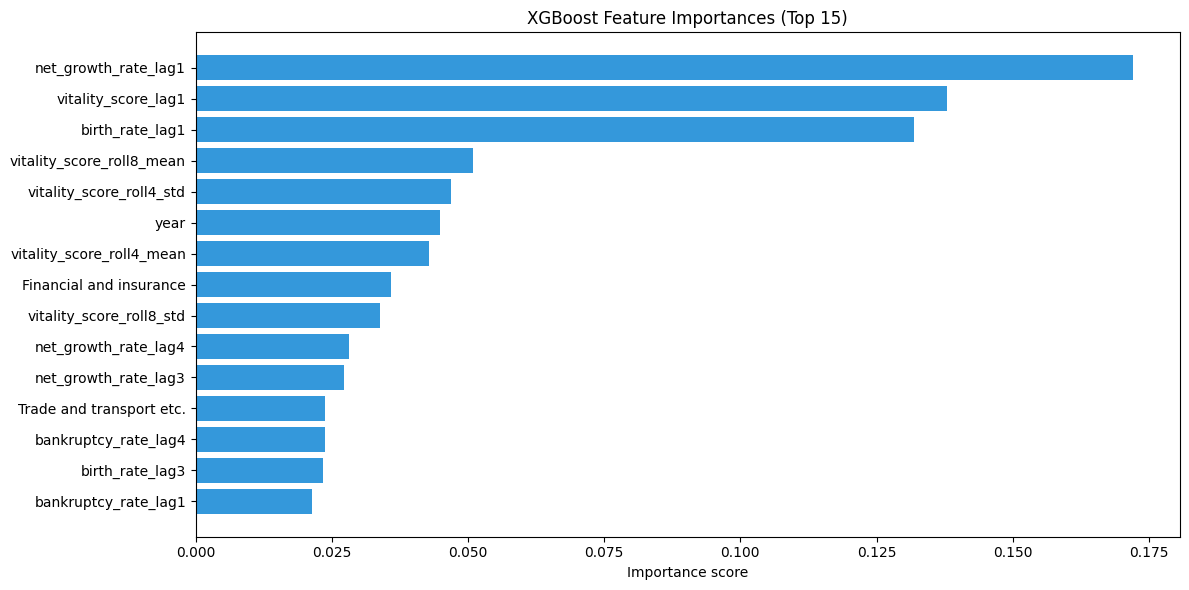

Top 5 most important features:
  net_growth_rate_lag1: 0.1721
  vitality_score_lag1: 0.1380
  birth_rate_lag1: 0.1319
  vitality_score_roll8_mean: 0.0510
  vitality_score_roll4_std: 0.0468


In [8]:
import pandas as pd
from src.dst_client import DSTClient

# Pull sector names from DST API
client = DSTClient(language='en')
info = client.get_table_info('DEMO14')
branch_var = next(v for v in info['variables'] if v['id'] == 'BRANCHEDB0710')
sector_names = {
    f"sector_{v['id']}": v['text'].split(' ', 1)[1] if ' ' in v['text'] else v['text']
    for v in branch_var['values']
    if v['id'] not in ('TOT', '11')
}

importances = pd.Series(xgb_result['feature_importances']).sort_values(ascending=False)

# Replace sector codes with readable names in the index
importances.index = [sector_names.get(idx, idx) for idx in importances.index]

fig, ax = plt.subplots(figsize=(12, 6))
top15 = importances.head(15)
ax.barh(top15.index[::-1], top15.values[::-1], color='#3498db')
ax.set_title('XGBoost Feature Importances (Top 15)', fontsize=12)
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('../artifacts/reports/fig_feature_importances.png', dpi=120)
plt.show()

print("Top 5 most important features:")
for feat, imp in importances.head(5).items():
    print(f"  {feat}: {imp:.4f}")

## 3.6 Log to MLflow
All experiments are tracked in MLflow, parameters, metrics, and models.
This enables model versioning and reproducibility.


In [9]:
import mlflow
import os

# Use a short absolute path to avoid Windows 260-char path limit
mlflow_dir = "C:/mlflow"
os.makedirs(mlflow_dir, exist_ok=True)
mlflow.set_tracking_uri(f"file:///{mlflow_dir}")

from src.model import log_to_mlflow, save_model

In [10]:
import mlflow
from src.model import log_to_mlflow, save_model

ridge_run_id = log_to_mlflow(
    ridge_result, feature_cols,
    tracking_uri='file:///C:/mlflow',
    experiment_name='dst_sector_health',
)

xgb_run_id = log_to_mlflow(
    xgb_result, feature_cols,
    tracking_uri='file:///C:/mlflow',
    experiment_name='dst_sector_health',
)

print("View experiments: mlflow ui --backend-store-uri C:/mlflow")
print(f"Ridge run ID:   {ridge_run_id}")
print(f"XGBoost run ID: {xgb_run_id}")

2026/04/16 17:21:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 17:21:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'sector_health_ridge' already exists. Creating a new version of this model...
Created version '13' of model 'sector_health_ridge'.
2026-04-16 17:21:47,619 [INFO] MLflow run logged: 92e0a0b88e3f41b1b1feac630f8e9d12
2026/04/16 17:21:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 17:21:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'sector_health_xgboost' already exists. Creating a new version of this model...
Created version '13' of model 'sector_health_xgboost'.
2026-04-16 

View experiments: mlflow ui --backend-store-uri C:/mlflow
Ridge run ID:   92e0a0b88e3f41b1b1feac630f8e9d12
XGBoost run ID: bc83b1615b1c4b7aa9ce2161a1bc3674


In [11]:
# Model is saved
from src.model import save_model

ridge_path = save_model(ridge_result, feature_cols, model_dir='../artifacts/models')
xgb_path   = save_model(xgb_result, feature_cols, model_dir='../artifacts/models')

print(f"Ridge model saved:   {ridge_path}")
print(f"XGBoost model saved: {xgb_path}")
print("\nThe 'model_latest.joblib' is what the API and monitoring use.")


2026-04-16 17:21:49,899 [INFO] Model saved → ../artifacts/models/ridge_20260416_172149.joblib
2026-04-16 17:21:49,907 [INFO] Model saved → ../artifacts/models/xgboost_20260416_172149.joblib


Ridge model saved:   ../artifacts/models/ridge_20260416_172149.joblib
XGBoost model saved: ../artifacts/models/xgboost_20260416_172149.joblib

The 'model_latest.joblib' is what the API and monitoring use.
